In [13]:
import os, json

# Load config from Notebook 1 output
config_path = '/kaggle/input/notebooks/asmidagar12/notebook1/config.json'

with open(config_path) as f:
    config = json.load(f)

DATASET_ROOT = config['DATASET_ROOT']
TRAIN_IMG    = config['TRAIN_IMG']
TRAIN_LBL    = config['TRAIN_LBL']
VAL_IMG      = config['VAL_IMG']
VAL_LBL      = config['VAL_LBL']
TEST_IMG     = config['TEST_IMG']
TEST_LBL     = config['TEST_LBL']
CLASS_NAMES  = config['CLASS_NAMES']
OUTPUT_DIR   = '/kaggle/working'

os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Config loaded successfully!")
print(json.dumps(config, indent=2))

Config loaded successfully!
{
  "DATASET_ROOT": "/kaggle/input/datasets/sayedgamal99/smoke-fire-detection-yolo",
  "TRAIN_IMG": "/kaggle/input/datasets/sayedgamal99/smoke-fire-detection-yolo/data/train/images",
  "TRAIN_LBL": "/kaggle/input/datasets/sayedgamal99/smoke-fire-detection-yolo/data/train/labels",
  "VAL_IMG": "/kaggle/input/datasets/sayedgamal99/smoke-fire-detection-yolo/data/val/images",
  "VAL_LBL": "/kaggle/input/datasets/sayedgamal99/smoke-fire-detection-yolo/data/val/labels",
  "TEST_IMG": "/kaggle/input/datasets/sayedgamal99/smoke-fire-detection-yolo/data/test/images",
  "TEST_LBL": "/kaggle/input/datasets/sayedgamal99/smoke-fire-detection-yolo/data/test/labels",
  "YAML_PATH": "/kaggle/working/dfire_dataset.yaml",
  "CLASS_NAMES": [
    "smoke",
    "fire"
  ],
  "OUTPUT_DIR": "/kaggle/working",
  "IMG_SIZE": 640
}


In [14]:
!pip install ultralytics -q

import torch
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO

print("GPU available :", torch.cuda.is_available())
print("GPU name      :", torch.cuda.get_device_name(0))
print("Libraries ready!")

GPU available : True
GPU name      : Tesla T4
Libraries ready!


In [15]:
yaml_content = f"""path: {DATASET_ROOT}
train: data/train/images
val: data/val/images
test: data/test/images

nc: 2
names: ['smoke', 'fire']
"""

yaml_path = os.path.join(OUTPUT_DIR, 'dfire_dataset.yaml')
with open(yaml_path, 'w') as f:
    f.write(yaml_content)

print("YAML saved at:", yaml_path)
print(yaml_content)

YAML saved at: /kaggle/working/dfire_dataset.yaml
path: /kaggle/input/datasets/sayedgamal99/smoke-fire-detection-yolo
train: data/train/images
val: data/val/images
test: data/test/images

nc: 2
names: ['smoke', 'fire']



In [16]:
# Load pretrained YOLOv8 nano model
model = YOLO('yolov8n.pt')

print("Starting training...")
print("This will take approximately 60-90 minutes for 30 epochs\n")

results = model.train(
    data      = yaml_path,
    epochs    = 30,
    imgsz     = 640,
    batch     = 16,
    name      = 'fire_smoke_detector',
    project   = OUTPUT_DIR,
    device    = 0,
    patience  = 10,
    optimizer = 'Adam',
    lr0       = 0.001,
    augment   = True,
    cache     = True,       # cache images in RAM for faster training
    workers   = 4,
    verbose   = True,
)

print("\n" + "="*45)
print("Training Complete!")
print("="*45)
print("Best model saved at:",
      os.path.join(OUTPUT_DIR, 'fire_smoke_detector/weights/best.pt'))

Starting training...
This will take approximately 60-90 minutes for 30 epochs

Ultralytics 8.4.36 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/dfire_dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=fire_smoke_detector2, nbs=64, nms=

In [18]:
import os

# Find where YOLO saved the results
for root, dirs, files_ in os.walk('/kaggle/working'):
    if len(files_) > 0:
        print(f"{root}/ ({len(files_)} files)")

/kaggle/working/ (3 files)
/kaggle/working/.virtual_documents/ (1 files)
/kaggle/working/fire_smoke_detector/ (1 files)
/kaggle/working/fire_smoke_detector2/ (22 files)
/kaggle/working/fire_smoke_detector2/weights/ (2 files)


Columns found: ['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss', 'lr/pg0', 'lr/pg1', 'lr/pg2']
    epoch     time  train/box_loss  train/cls_loss  train/dfl_loss  \
27     28  4263.48         1.34044         1.01678         1.31923   
28     29  4413.54         1.32675         1.00175         1.31574   
29     30  4564.46         1.30855         0.97354         1.29614   

    metrics/precision(B)  metrics/recall(B)  metrics/mAP50(B)  \
27               0.74180            0.67867           0.75157   
28               0.74432            0.67619           0.74902   
29               0.73805            0.69262           0.75408   

    metrics/mAP50-95(B)  val/box_loss  val/cls_loss  val/dfl_loss    lr/pg0  \
27              0.43449       1.27417       1.14795       1.21382  0.000109   
28              0.43255       1.27600       1.1

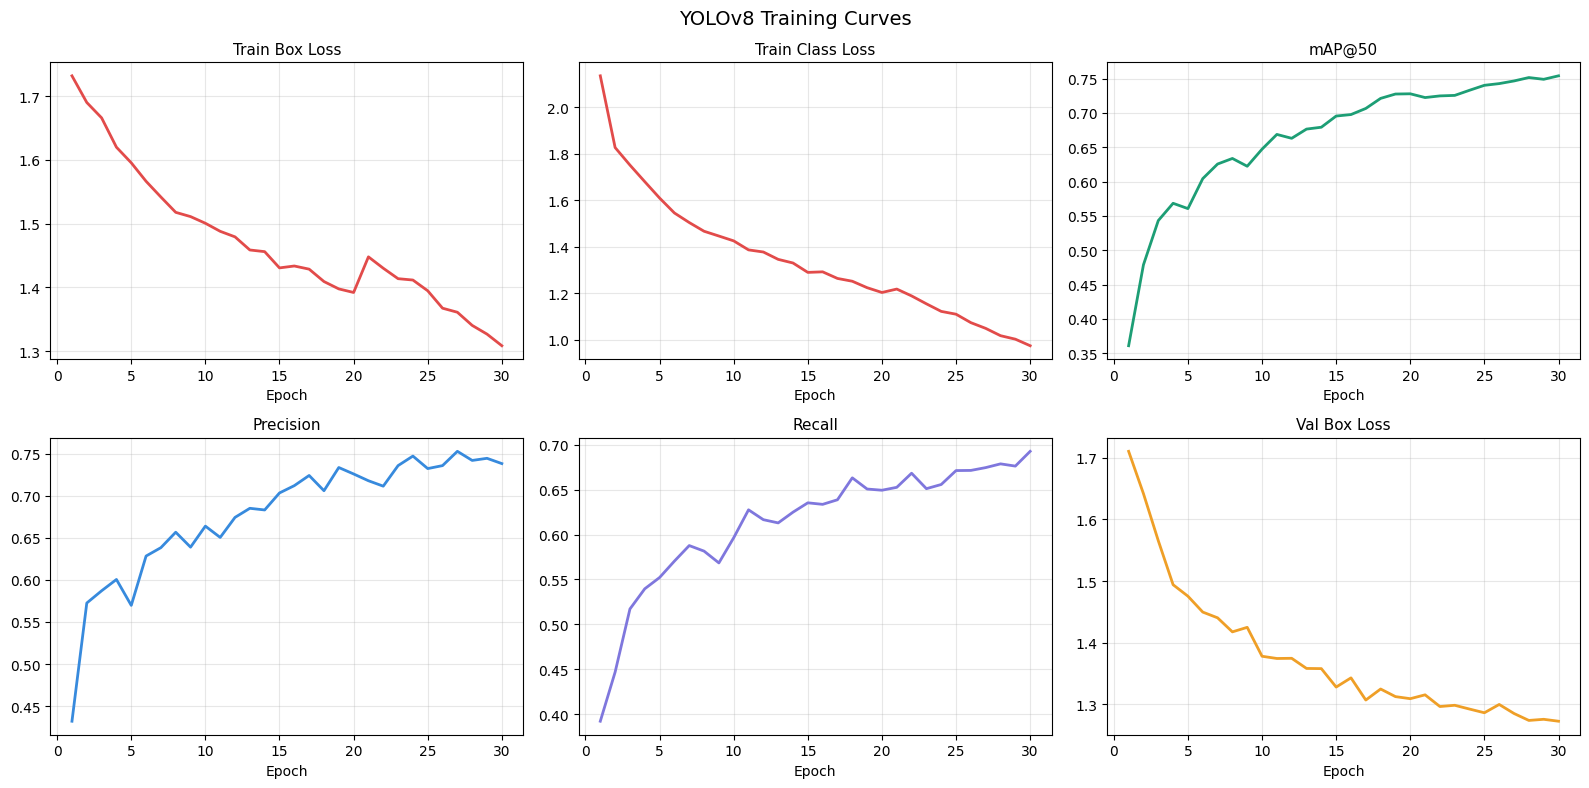

Saved training curves!


In [19]:
import pandas as pd

results_csv = '/kaggle/working/fire_smoke_detector2/results.csv'
df = pd.read_csv(results_csv)
df.columns = df.columns.str.strip()

print("Columns found:", list(df.columns))
print(df.tail(3))

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('YOLOv8 Training Curves', fontsize=14)

metrics = [
    ('train/box_loss',       'Train Box Loss',  '#E24B4A'),
    ('train/cls_loss',       'Train Class Loss','#E24B4A'),
    ('metrics/mAP50(B)',     'mAP@50',          '#1D9E75'),
    ('metrics/precision(B)', 'Precision',       '#378ADD'),
    ('metrics/recall(B)',    'Recall',          '#7F77DD'),
    ('val/box_loss',         'Val Box Loss',    '#EF9F27'),
]

for ax, (col, title, color) in zip(axes.flatten(), metrics):
    if col in df.columns:
        ax.plot(df['epoch'], df[col], color=color, linewidth=2)
        ax.set_title(title, fontsize=11)
        ax.set_xlabel('Epoch')
        ax.grid(True, alpha=0.3)
    else:
        ax.set_title(f'{title} (not found)')
        ax.axis('off')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'training_curves.png'), dpi=100)
plt.show()
print("Saved training curves!")

In [20]:
best_model_path = '/kaggle/working/fire_smoke_detector2/weights/best.pt'
model = YOLO(best_model_path)

print("Evaluating on validation set...")
metrics = model.val(
    data   = yaml_path,
    device = 0,
)

print("\n" + "="*45)
print("MODEL PERFORMANCE")
print("="*45)
print(f"mAP@50        : {metrics.box.map50:.4f}   (target > 0.80)")
print(f"mAP@50-95     : {metrics.box.map:.4f}")
print(f"Precision     : {metrics.box.mp:.4f}")
print(f"Recall        : {metrics.box.mr:.4f}")
print(f"\nPer class mAP@50:")
for i, name in enumerate(CLASS_NAMES):
    print(f"  {name:10s}: {metrics.box.ap50[i]:.4f}")

Evaluating on validation set...
Ultralytics 8.4.36 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 256.5±272.4 MB/s, size: 130.4 KB)
val: Scanning /kaggle/input/datasets/sayedgamal99/smoke-fire-detection-yolo/data/val/labels... 3094 images, 1375 backgrounds, 5 corrupt: 100% ━━━━━━━━━━━━ 3099/3099 717.1it/s 4.3s0.0s
val: /kaggle/input/datasets/sayedgamal99/smoke-fire-detection-yolo/data/val/images/WEB07535.jpg: ignoring corrupt image/label: [Errno 30] Read-only file system: '/kaggle/input/datasets/sayedgamal99/smoke-fire-detection-yolo/data/val/images/WEB07535.jpg'
val: /kaggle/input/datasets/sayedgamal99/smoke-fire-detection-yolo/data/val/images/WEB07536.jpg: ignoring corrupt image/label: [Errno 30] Read-only file system: '/kaggle/input/datasets/sayedgamal99/smoke-fire-detection-yolo/data/val/images/WEB07536.jpg'
val: /kaggle/input/datasets/s

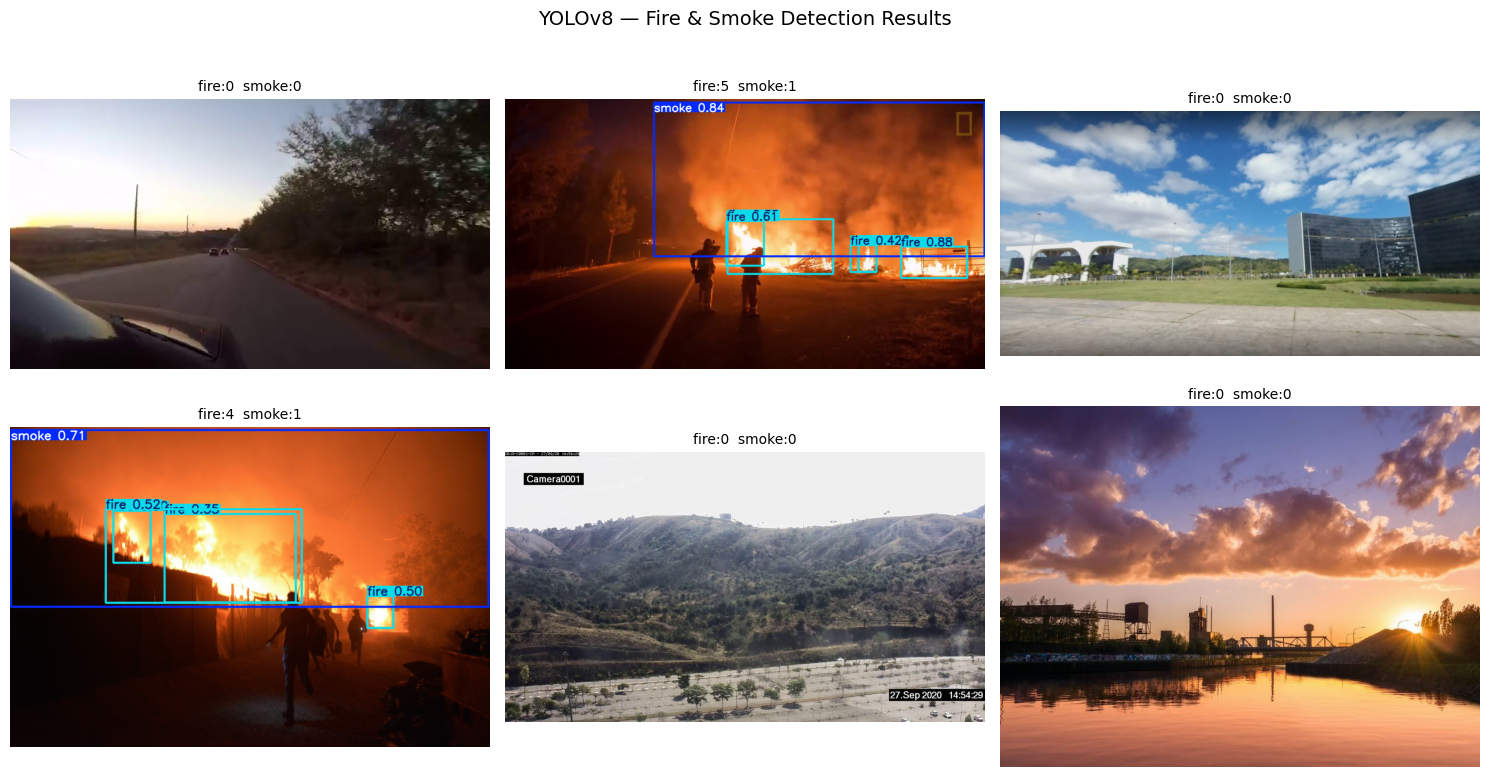

Saved test results!


In [21]:
test_files = [f for f in os.listdir(TEST_IMG)
              if f.endswith(('.jpg','.png','.jpeg'))]
samples = random.sample(test_files, 6)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('YOLOv8 — Fire & Smoke Detection Results', fontsize=14)

for ax, fname in zip(axes.flatten(), samples):
    img_path = os.path.join(TEST_IMG, fname)
    result   = model(img_path, conf=0.25, verbose=False)[0]
    img      = cv2.cvtColor(result.plot(), cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.axis('off')
    n_fire  = sum(1 for c in result.boxes.cls if int(c)==1)
    n_smoke = sum(1 for c in result.boxes.cls if int(c)==0)
    ax.set_title(f'fire:{n_fire}  smoke:{n_smoke}', fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'test_results.png'), dpi=100)
plt.show()
print("Saved test results!")

In [22]:
inference_code = '''
import cv2
import torch
import numpy as np
from ultralytics import YOLO

MODEL_PATH  = '/kaggle/input/notebook2-output/fire_smoke_detector2/weights/best.pt'
CLASS_NAMES = ['smoke', 'fire']
model       = YOLO(MODEL_PATH)

def run_yolo_on_frame(frame, conf_threshold=0.25):
    """
    Run YOLOv8 on a single frame.
    Input  : frame (numpy array, BGR)
    Output : dict with detections
    """
    result     = model(frame, conf=conf_threshold, verbose=False)[0]
    detections = []

    for box in result.boxes:
        cls          = int(box.cls)
        conf         = float(box.conf)
        x1,y1,x2,y2 = map(int, box.xyxy[0])
        detections.append({
            'class'      : CLASS_NAMES[cls],
            'confidence' : round(conf, 4),
            'bbox'       : [x1, y1, x2, y2]
        })

    return {
        'detections'   : detections,
        'n_fire'       : sum(1 for d in detections if d['class']=='fire'),
        'n_smoke'      : sum(1 for d in detections if d['class']=='smoke'),
        'max_conf'     : max((d['confidence'] for d in detections), default=0.0),
        'frame_height' : frame.shape[0],
        'frame_width'  : frame.shape[1],
    }
'''

func_path = os.path.join(OUTPUT_DIR, 'yolo_inference.py')
with open(func_path, 'w') as f:
    f.write(inference_code)

print("Inference function saved!")

Inference function saved!


In [23]:
nb2_config = {
    'DATASET_ROOT'   : DATASET_ROOT,
    'TRAIN_IMG'      : TRAIN_IMG,
    'TRAIN_LBL'      : TRAIN_LBL,
    'VAL_IMG'        : VAL_IMG,
    'VAL_LBL'        : VAL_LBL,
    'TEST_IMG'       : TEST_IMG,
    'TEST_LBL'       : TEST_LBL,
    'CLASS_NAMES'    : CLASS_NAMES,
    'OUTPUT_DIR'     : OUTPUT_DIR,
    'BEST_MODEL'     : best_model_path,
    'YAML_PATH'      : yaml_path,
    'map50'          : round(metrics.box.map50, 4),
    'precision'      : round(metrics.box.mp, 4),
    'recall'         : round(metrics.box.mr, 4),
}

nb2_config_path = os.path.join(OUTPUT_DIR, 'nb2_config.json')
with open(nb2_config_path, 'w') as f:
    json.dump(nb2_config, f, indent=2)

print("=" * 45)
print("  Notebook 2 COMPLETE!")
print("=" * 45)
print(f"\nFiles saved to {OUTPUT_DIR}:")
for fname in os.listdir(OUTPUT_DIR):
    fpath = os.path.join(OUTPUT_DIR, fname)
    if os.path.isfile(fpath):
        size = os.path.getsize(fpath)
        print(f"  {fname:45s} {size/1024:.1f} KB")

  Notebook 2 COMPLETE!

Files saved to /kaggle/working:
  yolov8n.pt                                    6396.3 KB
  nb2_config.json                               0.9 KB
  yolo_inference.py                             1.1 KB
  training_curves.png                           109.9 KB
  test_results.png                              1122.5 KB
  yolo26n.pt                                    5414.5 KB
  dfire_dataset.yaml                            0.2 KB
